## **Продвинутые методы обучения регрессионных моделей и работа с несбалансированными данными**

### SGD-регрессия

Мы уже знаем, что обычная линейная регрессия решается аналитически через метод наименьших квадратов:

```
β = (X^T X)^(-1) X^T y
```

Почему нет эпох и learning rate?

- Это аналитическое решение в замкнутой форме — математическое выражение, позволяющее найти точный ответ за конечное число операций (сложение, умножение, возведение в степень, логарифмы и т.д.)
- Решение получается путем решения системы линейных уравнений
- Мы находим точное решение данного уравнения за один шаг

Что считает регрессия?
β = (XᵀX)⁻¹ Xᵀy

Это алгоритм из 3-х этапов

Этап 1: A = XᵀX

Перемножаем матрицы — каждый признак с каждым. XᵀX:

- матрица попарных произведений признаков
- один элемент (i,j) матрицы = сумма произведений i-го и j-го признака по всем объектам
- показывает, как признаки коррелируют друг с другом

> Это одна из причин, по которой в механизме внимания и многих эмбеддинговых моделях мы выполняем матричное умножение: ищем коррелирующие слова. Т.е. сильная связь между словами (высокий вес внимания в современных системах) буквально означает, что это слово влияет на появление другого слова в одном контексте (за "мобильный" следует "телефон"), либо одно слово влияет на изменение другого слова (ср. грамматические изменения: "талантливый студент -> талантливая студентка") и т.д.

Этап 2: A⁻¹

Решаем систему Aβ = b, где A = XᵀX, b = Xᵀy

Аналогия:

- Обычное уравнение 3x = 6
    - делим на 3 --> x = 6/3
- Матричное уравнение Aβ = b
    - умножаем на A⁻¹ --> β = A⁻¹b

Что делает обращение:

1. Находит такую матрицу, при умножении на которую A даёт единичную
2. Фактически "делит" систему уравнений. Такая матрица называется **обратной**



AA⁻¹=A⁻¹A=E

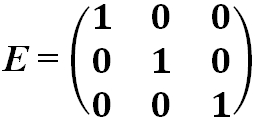

Этап 3: A⁻¹ · Xᵀ · y

Получаем коэффициенты β

- Xᵀy — вектор связей каждого признака с целевой переменной (признак × переменная)
- A⁻¹ — корректирует эти связи с учётом взаимосвязей признаков (признак × признак)


Большое количество признаков (например, 50 000 слов из CountVectorizer): размерность X^T X равна 50 000 × 50 000

**Это вычислительно затратно**

Решение: использовать метод, который *аппроксимирует*, а не вычисляет точный результат

**Простая аналогия**

Аналитическое решение = формула корней квадратного уравнения:
- подставляем число, получаем точный ответ

Градиентный спуск = "частичное" деление:
- делаем шаги, приближаемся к правильным ответам
- решаем: какой шаг сделать (больше или меньше) и когда остановиться (сколько итераций обучения нужно пройти)

In [ ]:
import numpy as np

# Данные: 3 текста, 2 признака
X = np.array([[1, 2],  # текст 1: слова A и B
              [2, 1],  # текст 2
              [3, 0]]) # текст 3
y = np.array([5, 4, 3])  # реальные оценки
β = np.array([1, 1])     # начальные веса


In [ ]:
# Считаем градиент вручную
m = len(y)
grad = np.zeros_like(β) # список нулей
print('Градиент:', grad)
print()

for i in range(m):
    print('Нужно угадать:', y[i])
    prediction = β[0]*X[i,0] + β[1]*X[i,1]  # ŷ = βᵀx_i
    print('Модель предсказала', prediction)
    error = y[i] - prediction                # ошибка
    print('Вычислена ошибка', error)
    for j in range(len(β)):
        grad[j] += -2/m * error * X[i, j]    # накопление градиента
        print('Обновили градиент:', grad)
        print()

Градиент: [0 0]

Нужно угадать: 5
Модель предсказала 3
Вычислена ошибка 2
Обновили градиент: [-1  0]

Обновили градиент: [-1 -2]

Нужно угадать: 4
Модель предсказала 3
Вычислена ошибка 1
Обновили градиент: [-2 -2]

Обновили градиент: [-2 -2]

Нужно угадать: 3
Модель предсказала 3
Вычислена ошибка 0
Обновили градиент: [-2 -2]

Обновили градиент: [-2 -2]



Градиент — вектор частных производных функции потерь по каждому параметру:
∇L(β) = [∂L/∂β₁, ∂L/∂β₂, ..., ∂L/∂β_d]

Размерность градиента = количеству признаков (напр., 50 000 для Bag-of-Words)

Компонента|	Что это|	Пример для 50k признаков
----------|--------|-------------------------
β_old|	Текущие веса|	Вектор [0.2, -0.5, 0.1, ..., 0.0]
∇L|	Градиент	|Вектор [-2.1, 1.3, -0.4, ..., 0.02]
η	|Learning rate (шаг)|	0.01
β_new|	Новые веса	|Старые веса − 0.01 · градиент

Функция потерь MSE:

L(β) = 1/m * Σ(y_i - β^T x_i)²

Градиент:

∇L(β) = -2/m * Σ(y_i - β^T x_i) * x_i

Обновление весов:

β = β - η * ∇L(β)

SGD (Stochastic Gradient Descent)

Вместо полного градиента используем градиент на одном случайном примере:

β = β - η * (-2 * (y_i - β^T x_i) * x_i)

Преимущества:

- Работает при ограничениях памяти
- Быстрее на больших данных
- Может выходить из локальных минимумов за счет стохастики

Недостатки:

- Шум
- Нестабильность
- Нужно задавать скорость обучения η

Сравнение методов

Метод|	Размер данных|	Скорость|	Память|	Точность
-----|-------|-------------|------------|-----------
LinearRegression|	< 10k признаков	|Быстро	|~O(n²)|	Оптимум
SGDRegressor	|> 10k признаков	|Очень быстро	|O(n)|	Близко к оптимуму

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Загружаем данные
categories = ['rec.sport.hockey', 'sci.space']
newsgroups = fetch_20newsgroups(subset='all', categories=categories,
                                shuffle=True, random_state=42)

# Создаём целевую переменную - длина текста (регрессия)
texts = newsgroups.data
y = np.array([len(text) for text in texts])

# Векторизация с большим количеством признаков
vectorizer = CountVectorizer(stop_words='english', max_features=10000)
X = vectorizer.fit_transform(texts)

# Разделяем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 1. Обычная линейная регрессия
print("LinearRegression (max_features=10000)")
start_time = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_time = time.time() - start_time

y_pred_lr = lr.predict(X_test)
print(f"Время обучения: {lr_time:.2f} сек")
print(f"MSE: {mean_squared_error(y_test, y_pred_lr):.0f}")
print(f"R^2: {r2_score(y_test, y_pred_lr):.3f}")
print()

# 2. SGD регрессия
print("SGDRegressor (max_features=10000)")
start_time = time.time()
sgd = SGDRegressor(max_iter=10000, random_state=42)
sgd.fit(X_train, y_train)
sgd_time = time.time() - start_time

y_pred_sgd = sgd.predict(X_test)
print(f"Время обучения: {sgd_time:.2f} сек")
print(f"MSE: {mean_squared_error(y_test, y_pred_sgd):.0f}")
print(f"R^2: {r2_score(y_test, y_pred_sgd):.3f}")

LinearRegression (max_features=10000)
Время обучения: 0.31 сек
MSE: 80681
R^2: 0.985

SGDRegressor (max_features=10000)
Время обучения: 0.01 сек
MSE: 751095270336718878801920
R^2: -142971680700801600.000


Увеличьте max_features до 50000. Что произойдёт с LinearRegression? А с SGDRegressor?

Изучите параметр learning_rate в SGDRegressor. Попробуйте разные стратегии.

In [ ]:
# Увеличение max_features до 50000

# Векторизация с большим количеством признаков
vectorizer = CountVectorizer(stop_words='english', max_features=50000)
X = vectorizer.fit_transform(texts)

# Разделяем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 1. Обычная линейная регрессия
print("LinearRegression (max_features=50000)")
start_time = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_time = time.time() - start_time

y_pred_lr = lr.predict(X_test)
print(f"Время обучения: {lr_time:.2f} сек")
print(f"MSE: {mean_squared_error(y_test, y_pred_lr):.0f}")
print(f"R^2: {r2_score(y_test, y_pred_lr):.3f}")
print()

# 2. SGD регрессия
print("SGDRegressor (max_features=50000)")
start_time = time.time()
sgd = SGDRegressor(max_iter=10000, random_state=42)
sgd.fit(X_train, y_train)
sgd_time = time.time() - start_time

y_pred_sgd = sgd.predict(X_test)
print(f"Время обучения: {sgd_time:.2f} сек")
print(f"MSE: {mean_squared_error(y_test, y_pred_sgd):.0f}")
print(f"R^2: {r2_score(y_test, y_pred_sgd):.3f}")

LinearRegression (max_features=50000)
Время обучения: 1.64 сек
MSE: 83941
R^2: 0.984

SGDRegressor (max_features=50000)
Время обучения: 0.14 сек
MSE: 513634538392077004177408
R^2: -97770810335384448.000


При увеличении max_features векторизатора в 5 раз пропорционально возрастает время обучения обоих типов регрессионных моделей. Качество линейной регрессии сопоставимо (и даже чуть хуже, чем с меньшим количеством признаков), регрессия с SGD обучилась лучше (значение MSE уменьшилось, R^2 увеличилось), но все еще сильно ошибается.

In [ ]:
for learning_rate in ['constant', 'optimal', 'adaptive', 'invscaling']:
    print(f"learning_rate='{learning_rate}'")

    start_time = time.time()
    sgd = SGDRegressor(max_iter=10000,
                       random_state=42,
                       learning_rate=learning_rate)
    sgd.fit(X_train, y_train)
    sgd_time = time.time() - start_time

    y_pred_sgd = sgd.predict(X_test)

    print(f"Время обучения: {sgd_time:.2f} сек")
    print(f"MSE: {mean_squared_error(y_test, y_pred_sgd):.0f}")
    print(f"R^2: {r2_score(y_test, y_pred_sgd):.3f}\n")

learning_rate='constant'
Время обучения: 0.02 сек
MSE: 99071142084739546459668480
R^2: -18858283698755268608.000

learning_rate='optimal'
Время обучения: 0.06 сек
MSE: 13353647573947620735978569728
R^2: -2541879189676662718464.000

learning_rate='adaptive'
Время обучения: 7.38 сек
MSE: 5056081445804847398912
R^2: -962429788357992.000

learning_rate='invscaling'
Время обучения: 0.02 сек
MSE: 513634538392077004177408
R^2: -97770810335384448.000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


При адаптивном learning rate время обучения возрастает в сотни раз, однако и среднеквадратичное значение ошибки становится намного меньше. Наименее эффективно модель обучается с оптимальным lr. Наиболее сбалансированная опция - inverse scaling lr (значение параметра по умолчанию), так как с ним регрессионная модель обучается быстро и не слишком уступает по качеству адаптивному lr.

## Дисбаланс классов

In [ ]:
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Создаём искусственный дисбаланс
# Оставляем все тексты про хоккей, берём только 10% текстов про космос
hockey_idx = [i for i, label in enumerate(newsgroups.target) if label == 0]
space_idx = [i for i, label in enumerate(newsgroups.target) if label == 1]

hockey_texts = [texts[i] for i in hockey_idx]
space_texts = [texts[i] for i in space_idx]

# Искусственно уменьшаем класс космоса
np.random.seed(42)
space_small_idx = np.random.choice(len(space_texts), size=int(len(space_texts) * 0.3), replace=False)
space_texts_small = [space_texts[i] for i in space_small_idx]

# Собираем несбалансированный датасет
texts_imbalanced = list(hockey_texts) + list(space_texts_small)
y_imbalanced = [0] * len(hockey_texts) + [1] * len(space_texts_small)

print(f"Размер датасета: {len(texts_imbalanced)}")
print(f"Хоккей: {len(hockey_texts)}")
print(f"Космос: {len(space_texts_small)}")

# Векторизация
vectorizer = CountVectorizer(stop_words='english', max_features=5000)
X_imb = vectorizer.fit_transform(texts_imbalanced)

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X_imb, y_imbalanced, test_size=0.2, random_state=42, stratify=y_imbalanced
)

# Базовая модель
lr_base = LogisticRegression(max_iter=1000)
lr_base.fit(X_train, y_train)
y_pred_base = lr_base.predict(X_test)

print("\nБез балансировки")
print(classification_report(y_test, y_pred_base, target_names=['hockey', 'space']))

Размер датасета: 1295
Хоккей: 999
Космос: 296

Без балансировки
              precision    recall  f1-score   support

      hockey       0.98      0.99      0.99       200
       space       0.98      0.92      0.95        59

    accuracy                           0.98       259
   macro avg       0.98      0.96      0.97       259
weighted avg       0.98      0.98      0.98       259



1: Oversampling через повторение

In [ ]:
from sklearn.utils import resample
from scipy.sparse import vstack

hockey_idx = [i for i, label in enumerate(y_train) if label == 0]
space_idx = [i for i, label in enumerate(y_train) if label == 1]

X_train_hockey = [texts[i] for i in hockey_idx]
X_train_space = [texts[i] for i in space_idx]

# 1. Явно преобразуем в numpy массивы
X_train_hockey_dense = vectorizer.transform(X_train_hockey)
X_train_space_dense = vectorizer.transform(X_train_space)

print(f"Хоккей: {X_train_hockey_dense.shape}")
print(f"Космос: {X_train_space_dense.shape}")

# 2. Ресэмплим
X_train_space_oversampled = resample(
    X_train_space_dense,
    replace=True,
    n_samples=X_train_hockey_dense.shape[0],
    random_state=42
)

# 3. Объединяем
X_train_balanced = vstack([X_train_hockey_dense, X_train_space_oversampled])
y_train_balanced = np.hstack([
    np.zeros(X_train_hockey_dense.shape[0]),
    np.ones(X_train_space_oversampled.shape[0])
])

# 4. Обучаем
lr_balanced = LogisticRegression(max_iter=10000)
lr_balanced.fit(X_train_balanced, y_train_balanced)
y_pred_balanced = lr_balanced.predict(X_test)

print("\nПосле oversampling")
print(classification_report(y_test, y_pred_balanced, target_names=['hockey', 'space']))

Хоккей: (799, 5000)
Космос: (237, 5000)

После oversampling
              precision    recall  f1-score   support

      hockey       0.82      0.77      0.80       200
       space       0.36      0.44      0.40        59

    accuracy                           0.69       259
   macro avg       0.59      0.61      0.60       259
weighted avg       0.72      0.69      0.70       259



Oversampling доказывает ненадежность:
1. Создаёт копии данных, а не вариативную выборку
2. Может отрицательно повлиять на обучение

2: Undersampling

In [ ]:
# Уменьшаем частый класс (хоккей)
hockey_texts_undersampled = resample(
    X_train_hockey_dense,
    replace=False,
    n_samples=X_train_space_dense.shape[0],
    random_state=42
)

X_train_balanced = vstack([hockey_texts_undersampled, X_train_space_dense])
y_train_balanced = np.hstack([
    np.zeros(hockey_texts_undersampled.shape[0]),
    np.ones(X_train_space_dense.shape[0])
])

lr_undersampled = LogisticRegression(max_iter=1000)
lr_undersampled.fit(X_train_balanced, y_train_balanced)

y_pred_undersampled = lr_undersampled.predict(X_test)

print("\nПосле undersampling")
print(classification_report(y_test, y_pred_undersampled, target_names=['hockey', 'space']))


После undersampling
              precision    recall  f1-score   support

      hockey       0.84      0.51      0.64       200
       space       0.29      0.68      0.41        59

    accuracy                           0.55       259
   macro avg       0.57      0.59      0.52       259
weighted avg       0.72      0.55      0.58       259



3: Взвешивание классов

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Вычисляем веса автоматически
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), weights))

lr_weighted = LogisticRegression(class_weight=class_weight_dict, max_iter=1000)
lr_weighted.fit(X_train, y_train)
y_pred_weighted = lr_weighted.predict(X_test)

print("\nС весами классов")
print(classification_report(y_test, y_pred_weighted, target_names=['hockey', 'space']))


С весами классов
              precision    recall  f1-score   support

      hockey       0.98      0.99      0.99       200
       space       0.96      0.93      0.95        59

    accuracy                           0.98       259
   macro avg       0.97      0.96      0.97       259
weighted avg       0.98      0.98      0.98       259



## 3: Feature engineering

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF векторизация
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_tfidf = tfidf.fit_transform(texts_imbalanced)

# Разделяем
X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(
    X_tfidf, y_imbalanced, test_size=0.2, random_state=42, stratify=y_imbalanced
)

# Обучаем
lr_tfidf = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_tfidf.fit(X_train_tf, y_train_tf)
y_pred_tfidf = lr_tfidf.predict(X_test_tf)

print("TF-IDF")
print(classification_report(y_test_tf, y_pred_tfidf, target_names=['hockey', 'space']))

TF-IDF
              precision    recall  f1-score   support

      hockey       0.98      0.99      0.99       200
       space       0.96      0.93      0.95        59

    accuracy                           0.98       259
   macro avg       0.97      0.96      0.97       259
weighted avg       0.98      0.98      0.98       259



In [ ]:
# Только униграммы
vec_unigram = CountVectorizer(stop_words='english', ngram_range=(1, 1), max_features=5000)

# Униграммы + биграммы
vec_bigram = CountVectorizer(stop_words='english', ngram_range=(1, 2), max_features=5000)

# Униграммы + биграммы + триграммы
vec_trigram = CountVectorizer(stop_words='english', ngram_range=(1, 3), max_features=5000)

# Обучите и сравните модели
for vectorizer, vect_type in [
    (vec_unigram, 'униграммы'),
    (vec_bigram, 'униграммы + биграммы'),
    (vec_trigram, 'униграммы + биграммы + триграммы')
    ]:
    X = vectorizer.fit_transform(texts_imbalanced)
    X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(
        X, y_imbalanced, test_size=0.2, random_state=42, stratify=y_imbalanced
    )

    lr_tfidf = LogisticRegression(class_weight='balanced', max_iter=1000)
    lr_tfidf.fit(X_train_tf, y_train_tf)
    y_pred_tfidf = lr_tfidf.predict(X_test_tf)

    print(f"Векторы: {vect_type}")
    print(classification_report(y_test_tf, y_pred_tfidf, target_names=['hockey', 'space']))

Векторы: униграммы
              precision    recall  f1-score   support

      hockey       0.98      0.99      0.99       200
       space       0.96      0.93      0.95        59

    accuracy                           0.98       259
   macro avg       0.97      0.96      0.97       259
weighted avg       0.98      0.98      0.98       259

Векторы: униграммы + биграммы
              precision    recall  f1-score   support

      hockey       0.98      0.99      0.99       200
       space       0.98      0.93      0.96        59

    accuracy                           0.98       259
   macro avg       0.98      0.96      0.97       259
weighted avg       0.98      0.98      0.98       259

Векторы: униграммы + биграммы + триграммы
              precision    recall  f1-score   support

      hockey       0.98      0.99      0.99       200
       space       0.98      0.93      0.96        59

    accuracy                           0.98       259
   macro avg       0.98      0.96    

Добавление биграмм дает прирост +0,02 precision для класса space, с последующим добавлением триграмм качество классификации не меняется.

In [ ]:
from scipy.sparse import hstack

# 1. Базовые текстовые признаки
vectorizer = CountVectorizer(stop_words='english', max_features=3000)
X_text = vectorizer.fit_transform(texts_imbalanced)

# 2. Создаём дополнительные признаки
additional_features = []

for text in texts_imbalanced:
    features = []
    # Длина текста
    features.append(len(text))
    # Количество заглавных букв
    features.append(sum(1 for c in text if c.isupper()))
    # Количество восклицательных знаков
    features.append(text.count('!'))
    # Количество вопросительных знаков
    features.append(text.count('?'))
    # Есть ли ссылка
    features.append(1 if 'http' in text or 'www' in text else 0)

    additional_features.append(features)

X_extra = np.array(additional_features)

# Нормализуем дополнительные признаки
scaler = StandardScaler()
X_extra_scaled = scaler.fit_transform(X_extra)

# Объединяем с текстовыми признаками
X_combined = hstack([X_text, X_extra_scaled])

# Разделяем и обучаем
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_imbalanced, test_size=0.2, random_state=42, stratify=y_imbalanced
)

lr_combined = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_combined.fit(X_train, y_train)
y_pred_combined = lr_combined.predict(X_test)

print("С дополнительными признаками")
print(classification_report(y_test, y_pred_combined, target_names=['hockey', 'space']))

С дополнительными признаками
              precision    recall  f1-score   support

      hockey       0.98      0.99      0.99       200
       space       0.96      0.93      0.95        59

    accuracy                           0.98       259
   macro avg       0.97      0.96      0.97       259
weighted avg       0.98      0.98      0.98       259



---

# Домашнее задание: полный пайплайн

## SGD-регрессия (3 балла)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
# Задача: предсказать длину текста
# 1. Загрузите 20newsgroups с категориями ['rec.sport.hockey', 'sci.space', 'talk.politics.mideast']
categories = ['rec.sport.hockey', 'sci.space', 'talk.politics.mideast']
newsgroups = fetch_20newsgroups(subset='all', categories=categories,
                                shuffle=True, random_state=42)

# 2. Создайте целевую переменную - количество символов в тексте
texts = newsgroups.data
y = np.array([len(text) for text in texts])

# 3. Сделайте TF-IDF векторизацию с max_features=20000
vectorizer = TfidfVectorizer(stop_words='english', max_features=20000)
X = vectorizer.fit_transform(texts)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 4. Обучите SGDRegressor с параметрами:
#    - max_iter=1000
#    - random_state=42
#    - learning_rate='adaptive'
#    - eta0=0.01
start_time = time.time()
sgd = SGDRegressor(max_iter=1000,
                   random_state=42,
                   learning_rate='adaptive',
                   eta0=0.01)
sgd.fit(X_train, y_train)
sgd_time = time.time() - start_time

y_pred_sgd = sgd.predict(X_test)

# 5. Обучите LinearRegression (если позволяет память) или используйте часть данных
start_time = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_time = time.time() - start_time

y_pred_lr = lr.predict(X_test)

# 6. Сравните:
#    - Время обучения
#    - MSE и MAE
#    - R²
print("SGDRegressor")
print(f"Время обучения: {sgd_time:.2f} сек")
print(f"MSE: {mean_squared_error(y_test, y_pred_sgd):.0f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_sgd):.0f}")
print(f"R^2: {r2_score(y_test, y_pred_sgd):.3f}")

print("\nLinearRegression")
print(f"Время обучения: {lr_time:.2f} сек")
print(f"MSE: {mean_squared_error(y_test, y_pred_lr):.0f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.0f}")
print(f"R^2: {r2_score(y_test, y_pred_lr):.3f}")

SGDRegressor
Время обучения: 0.85 сек
MSE: 4931518
MAE: 1063
R^2: 0.683

LinearRegression
Время обучения: 2.07 сек
MSE: 6013348
MAE: 1400
R^2: 0.614


Время обучения линейной регрессии заметно больше (примерно в 2,5 раза), показатели MSE, MAE и R² свидетельствуют о сопоставимом качестве моделей, но у SGDRegressor более низкие метрики ошибок и R² на 0.07 больше, чем у LinearRegression.

## Балансировка классов (4 балла)

In [ ]:
from scipy.sparse import hstack, vstack
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
# Задача: классификация категорий с дисбалансом
# 1. Создайте несбалансированный датасет:
#    - Хоккей: 600 текстов
#    - Космос: 60 текстов (в 10 раз меньше)
hockey_idx = [i for i, label in enumerate(newsgroups.target) if label == 0]
space_idx = [i for i, label in enumerate(newsgroups.target) if label == 1]

hockey_texts = [texts[i] for i in hockey_idx]
space_texts = [texts[i] for i in space_idx]

# Искусственно уменьшаем классы
np.random.seed(42)
hockey_small_idx = np.random.choice(len(hockey_texts), size=600, replace=False)
hockey_texts_small = [hockey_texts[i] for i in hockey_small_idx]
space_small_idx = np.random.choice(len(space_texts), size=int(len(hockey_texts_small) * 0.1), replace=False)
space_texts_small = [space_texts[i] for i in space_small_idx]

# Собираем несбалансированный датасет
texts_imbalanced = list(hockey_texts_small) + list(space_texts_small)
y_imbalanced = [0] * len(hockey_texts_small) + [1] * len(space_texts_small)

print(f"Размер датасета: {len(texts_imbalanced)}")
print(f"Хоккей: {len(hockey_texts_small)}")
print(f"Космос: {len(space_texts_small)}")

Размер датасета: 660
Хоккей: 600
Космос: 60


In [ ]:
# 2. Векторизуйте тексты (CountVectorizer, max_features=3000)
vectorizer = CountVectorizer(stop_words='english', max_features=3000)
X_imb = vectorizer.fit_transform(texts_imbalanced)

# 3. Разделите на train/test (stratify!)
X_train, X_test, y_train, y_test = train_test_split(
    X_imb, y_imbalanced, test_size=0.2, random_state=42, stratify=y_imbalanced
)

# 4. Обучите 4 модели с разными стратегиями:
#    a) Без балансировки
#    b) С oversampling (повторением)
#    c) С undersampling
#    d) С весами классов (class_weight='balanced')

# 5. Для каждой модели выведите:
#    - classification_report
#    - confusion_matrix (визуализация)

def cm_visualization(y_test, y_pred):
    '''Функция для визуализации матрицы ошибок'''
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('предсказанный класс')
    plt.ylabel('истинный класс')
    plt.title('матрица ошибок')
    plt.show()

Без балансировки

              precision    recall  f1-score   support

      hockey       0.98      1.00      0.99       120
       space       1.00      0.83      0.91        12

    accuracy                           0.98       132
   macro avg       0.99      0.92      0.95       132
weighted avg       0.99      0.98      0.98       132



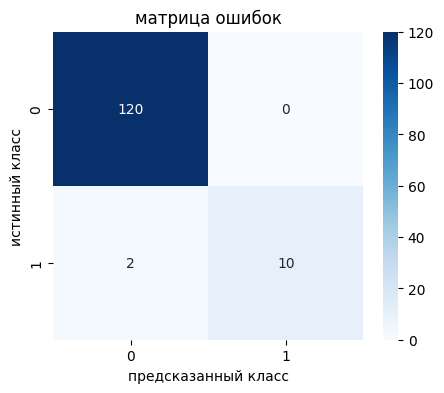

In [ ]:
# 4a. Без балансировки
lr_base = LogisticRegression(max_iter=1000)
lr_base.fit(X_train, y_train)
y_pred_base = lr_base.predict(X_test)

print("Без балансировки\n")
print(classification_report(y_test, y_pred_base, target_names=['hockey', 'space']))
cm_visualization(y_test, y_pred_base)

Хоккей: (600, 3000)
Космос: (60, 3000)

После oversampling

              precision    recall  f1-score   support

      hockey       1.00      1.00      1.00       120
       space       1.00      1.00      1.00        12

    accuracy                           1.00       132
   macro avg       1.00      1.00      1.00       132
weighted avg       1.00      1.00      1.00       132



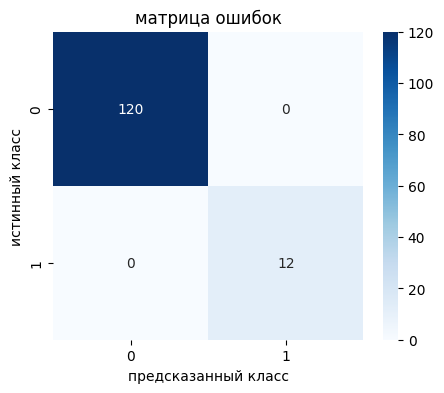

In [ ]:
# 4b. С oversampling

# Явно преобразуем в numpy массивы
X_train_hockey_dense = vectorizer.transform(hockey_texts_small)
X_train_space_dense = vectorizer.transform(space_texts_small)

print(f"Хоккей: {X_train_hockey_dense.shape}")
print(f"Космос: {X_train_space_dense.shape}")

# Ресэмплим
X_train_space_oversampled = resample(
    X_train_space_dense,
    replace=True,
    n_samples=X_train_hockey_dense.shape[0],
    random_state=42
)

# Объединяем
X_train_balanced = vstack([X_train_hockey_dense, X_train_space_oversampled])
y_train_balanced = np.hstack([
    np.zeros(X_train_hockey_dense.shape[0]),
    np.ones(X_train_space_oversampled.shape[0])
])

# Обучаем
lr_balanced = LogisticRegression(max_iter=1000)
lr_balanced.fit(X_train_balanced, y_train_balanced)
y_pred_balanced = lr_balanced.predict(X_test)

print("\nПосле oversampling\n")
print(classification_report(y_test, y_pred_balanced, target_names=['hockey', 'space']))
cm_visualization(y_test, y_pred_balanced)

После undersampling

              precision    recall  f1-score   support

      hockey       1.00      0.98      0.99       120
       space       0.86      1.00      0.92        12

    accuracy                           0.98       132
   macro avg       0.93      0.99      0.96       132
weighted avg       0.99      0.98      0.99       132



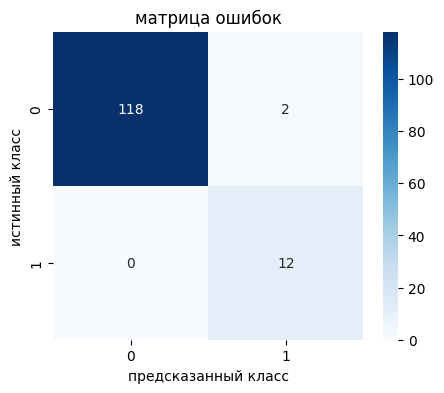

In [ ]:
# 4c. С undersampling

hockey_texts_undersampled = resample(
    X_train_hockey_dense,
    replace=False,
    n_samples=X_train_space_dense.shape[0],
    random_state=42
)

X_train_balanced = vstack([hockey_texts_undersampled, X_train_space_dense])
y_train_balanced = np.hstack([
    np.zeros(hockey_texts_undersampled.shape[0]),
    np.ones(X_train_space_dense.shape[0])
])

lr_undersampled = LogisticRegression(max_iter=1000)
lr_undersampled.fit(X_train_balanced, y_train_balanced)

y_pred_undersampled = lr_undersampled.predict(X_test)

print("После undersampling\n")
print(classification_report(y_test, y_pred_undersampled, target_names=['hockey', 'space']))
cm_visualization(y_test, y_pred_undersampled)

С весами классов

              precision    recall  f1-score   support

      hockey       1.00      1.00      1.00       120
       space       1.00      1.00      1.00        12

    accuracy                           1.00       132
   macro avg       1.00      1.00      1.00       132
weighted avg       1.00      1.00      1.00       132



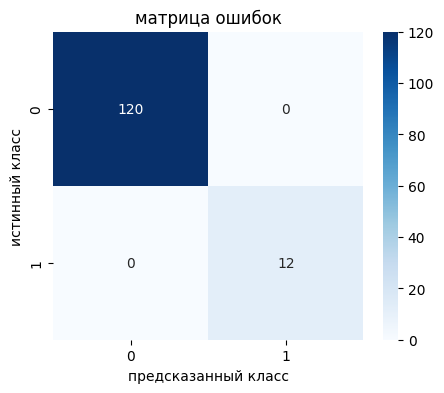

In [ ]:
# 4d. С весами классов

# Вычисляем веса автоматически
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), weights))

lr_weighted = LogisticRegression(class_weight=class_weight_dict, max_iter=1000)
lr_weighted.fit(X_train, y_train)
y_pred_weighted = lr_weighted.predict(X_test)

print("С весами классов\n")
print(classification_report(y_test, y_pred_weighted, target_names=['hockey', 'space']))
cm_visualization(y_test, y_pred_weighted)

`# 6. Сделайте вывод: какая стратегия лучше для редкого класса?`

Максимальные значения метрик качества достигаются с oversampling и весами классов. Обучение с добавлением весов классов является предпочтительным, так как oversampling просто копирует объекты, снижая вариативность данных.

## Feature engineering (1 балл)

In [ ]:
# Задача: улучшить модель через создание признаков
# 1. Возьмите сбалансированные данные из Части 2 (лучший метод)
# 2. Используйте TF-IDF для веткоризации
# 3. Сравните качество до и после добавления признаков

# TF-IDF векторизация
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_tfidf = tfidf.fit_transform(texts_imbalanced)

# Разделяем
X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(
    X_tfidf, y_imbalanced, test_size=0.2, random_state=42, stratify=y_imbalanced
)

# Обучаем
lr_tfidf = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_tfidf.fit(X_train_tf, y_train_tf)
y_pred_tfidf = lr_tfidf.predict(X_test_tf)

print("TF-IDF")
print(classification_report(y_test_tf, y_pred_tfidf, target_names=['hockey', 'space']))


# 1. Базовые текстовые признаки
vectorizer = CountVectorizer(stop_words='english', max_features=3000)
X_text = vectorizer.fit_transform(texts_imbalanced)

# 2. Создаём дополнительные признаки
additional_features = []

for text in texts_imbalanced:
    features = []
    # Длина текста
    features.append(len(text))
    # Количество заглавных букв
    features.append(sum(1 for c in text if c.isupper()))
    # Количество восклицательных знаков
    features.append(text.count('!'))
    # Количество вопросительных знаков
    features.append(text.count('?'))
    # Есть ли ссылка
    features.append(1 if 'http' in text or 'www' in text else 0)

    additional_features.append(features)

X_extra = np.array(additional_features)

# Нормализуем дополнительные признаки
scaler = StandardScaler()
X_extra_scaled = scaler.fit_transform(X_extra)

# Объединяем с текстовыми признаками
X_combined = hstack([X_text, X_extra_scaled])

# Разделяем и обучаем
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_imbalanced, test_size=0.2, random_state=42, stratify=y_imbalanced
)

lr_combined = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_combined.fit(X_train, y_train)
y_pred_combined = lr_combined.predict(X_test)

print("С дополнительными признаками")
print(classification_report(y_test, y_pred_combined, target_names=['hockey', 'space']))

TF-IDF
              precision    recall  f1-score   support

      hockey       1.00      1.00      1.00       120
       space       1.00      1.00      1.00        12

    accuracy                           1.00       132
   macro avg       1.00      1.00      1.00       132
weighted avg       1.00      1.00      1.00       132

С дополнительными признаками
              precision    recall  f1-score   support

      hockey       1.00      1.00      1.00       120
       space       1.00      1.00      1.00        12

    accuracy                           1.00       132
   macro avg       1.00      1.00      1.00       132
weighted avg       1.00      1.00      1.00       132



Качество до и после добавления дополнительных признаков не изменилось, достигается максимальное значение по всем метрикам (1.0).